# Metodologia Design Science Research (DSR)

**Etapa de Pesquisa (Peffers et al., 2007):**
### 4. Demonstração (Demonstration) e 5. Avaliação (Evaluation)

**Objetivo Acadêmico:** Este notebook inicia a fase de construção e teste do artefato preditivo. Segundo Hevner et al. (2004), a utilidade, qualidade e eficácia de um artefato de design devem ser rigorosamente demonstradas. Aqui, utilizamos modelos lineares clássicos (Benchmark) para estabelecer uma linha de base de desempenho (*Baseline*), contra a qual modelos mais complexos serão comparados.


# 07a - Modelagem: Regressão Linear e Regularizações
Neste notebook, exploramos a família de modelos lineares para prever o `total_servido`, utilizando as variáveis selecionadas via RFECV.

**Algoritmos incluídos:**
1. Regressão Linear Simples (OLS)
2. Ridge Regression (L2)
3. Lasso Regression (L1)
4. ElasticNet (L1 + L2)
5. Bayesian Ridge

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
import joblib
import os

# Configurações
BASE_SELECIONADA = '../data/base_features_selecionadas.csv'
TARGET = 'total_servido'

df = pd.read_csv(BASE_SELECIONADA)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')

print(f"📦 Base carregada: {df.shape[0]} registros.")

📦 Base carregada: 191 registros.


In [2]:
# Validação da Base 2023-2025
print(f"📊 Shape da base: {df.shape}")
print(f"📅 Período: {df['data'].min()} até {df['data'].max()}")

📊 Shape da base: (191, 52)
📅 Período: 2023-08-01 00:00:00 até 2025-08-22 00:00:00


In [3]:
# 1. Divisão Treino/Teste (Temporal)
train_size = int(len(df) * 0.8)
X_full = df.drop(columns=['data', TARGET])
y_full = df[TARGET]

X_train_full = X_full.iloc[:train_size]
y_train = y_full.iloc[:train_size]
X_test_full = X_full.iloc[train_size:]
y_test = y_full.iloc[train_size:]

# 2. Seleção de Variáveis Robustas (RFECV com RandomForest)
print("🔄 Selecionando variáveis via RFECV (isso pode demorar um pouco)... ")
rf = RandomForestRegressor(n_estimators=50, random_state=42)
selector = RFECV(estimator=rf, step=1, cv=5, scoring='neg_mean_absolute_error')
selector.fit(X_train_full, y_train)

selected_features = X_full.columns[selector.support_].tolist()
print(f"✅ RFECV concluído! Número ideal de variáveis: {len(selected_features)}")
print(f"📌 Features selecionadas: {selected_features}")

X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

# 3. Normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📈 Treino: {len(X_train)} dias | Teste: {len(X_test)} dias")

🔄 Selecionando variáveis via RFECV (isso pode demorar um pouco)... 
✅ RFECV concluído! Número ideal de variáveis: 5
📌 Features selecionadas: ['total_reservas', 'erro_planejamento_ontem', 'reservas_media_movel_5d', 'total_reservas_lag_2', 'reservas_media_movel_3d']
📈 Treino: 152 dias | Teste: 39 dias


In [4]:
# 3. Definição e Treinamento dos Modelos
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'BayesianRidge': BayesianRidge()
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        'Modelo': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

df_results = pd.DataFrame(results).sort_values('MAE')
display(df_results)

,Modelo,MAE,RMSE,R2
0,LinearRegression,22.468288,28.128200,0.384342
2,Lasso,22.468890,28.131521,0.384196
1,Ridge,22.517614,28.178175,0.382152
3,ElasticNet,22.811578,28.486791,0.368544
4,BayesianRidge,22.834931,28.510338,0.367500


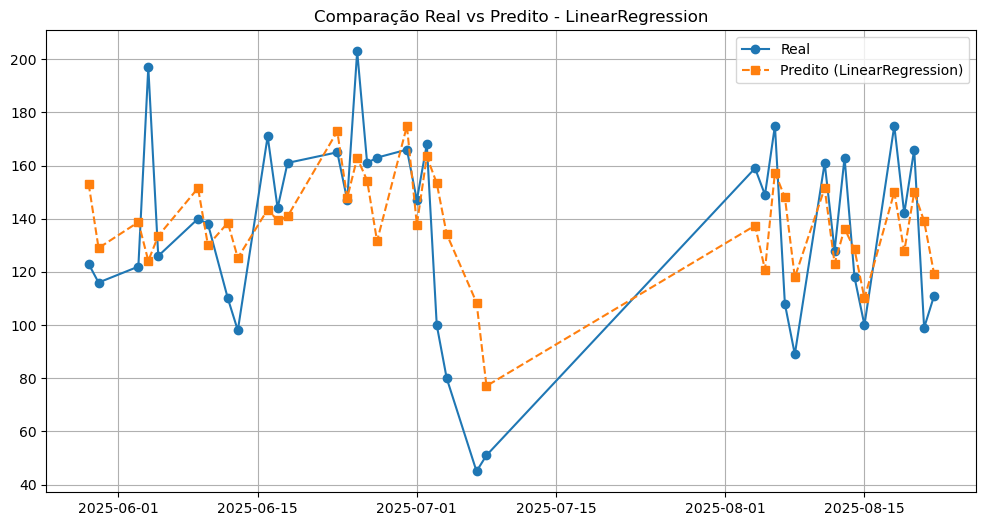

In [5]:
# 4. Visualização de Resultados (Melhor Modelo)
best_model_name = df_results.iloc[0]['Modelo']
best_model = models[best_model_name]
final_preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(12, 6))
plt.plot(df.iloc[train_size:]['data'], y_test, label='Real', marker='o')
plt.plot(df.iloc[train_size:]['data'], final_preds, label=f'Predito ({best_model_name})', linestyle='--', marker='s')
plt.title(f"Comparação Real vs Predito - {best_model_name}")
plt.legend()
plt.grid(True)
plt.show()